## Sanity-check the new data's distribution against DepMap

Runs before any saved model sees the new data, on purpose: a formatting bug
or a mismatched value scale should be visible here, not discovered later as
an implausible latent score.

Two checks:
- A shared UMAP of the new samples projected against the DepMap cohort, to
  see whether the new data lands inside the DepMap distribution or off to
  the side of it.
- Per-gene range, missingness, and overall-scale checks on the raw (pre-scaling)
  values, to catch a unit mismatch or a formatting bug that a UMAP plot alone
  might not make obvious.

Run this script with `8.apply-biobombe-new-data/` as the working directory.

In [1]:
import pathlib
import sys

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import umap

sys.path.insert(0, "../utils")
from data_loader import load_train_test_data

sys.path.insert(0, "utils")
import data_prep as dp

In [2]:
train_test_data_directory = pathlib.Path("../1.data-exploration/data").resolve()
scaler_path = pathlib.Path("results/depmap_gene_scaler.joblib")
data_results_dir = pathlib.Path("data/largaespada/results")
data_results_dir.mkdir(parents=True, exist_ok=True)

In [3]:
new_scaled_df = pd.read_parquet(data_results_dir / "NF1_data_model_ready_scaled.parquet")
scaler_bundle = joblib.load(scaler_path)
gene_order = scaler_bundle["gene_order"]

# drop_columns=False keeps ModelID and every gene (unfiltered, unscaled);
# subsetting to gene_order here gives exactly what the scaler was fit on.
train_raw_df = load_train_test_data(train_test_data_directory, train_or_test="train", drop_columns=False)
train_raw_df = train_raw_df[["ModelID"] + gene_order]

train_scaled = scaler_bundle["scaler"].transform(train_raw_df[gene_order].values.astype(np.float32))
train_scaled_df = pd.DataFrame(train_scaled, columns=gene_order)
train_scaled_df.insert(0, "ModelID", train_raw_df["ModelID"].values)

print(f"New data (scaled): {new_scaled_df.shape}")
print(f"Train data (scaled): {train_scaled_df.shape}")


# ### UMAP: new data projected against the training cohort

New data (scaled): (8, 2719)
Train data (scaled): (670, 2719)


### UMAP: new data projected against the DepMap cohort

In [4]:
combined = pd.concat(
    [train_scaled_df.assign(source="Train data"), new_scaled_df.assign(source="New data")],
    ignore_index=True,
)

reducer = umap.UMAP(random_state=0)
embedding = reducer.fit_transform(combined[gene_order].values)
combined["umap_1"] = embedding[:, 0]
combined["umap_2"] = embedding[:, 1]

/home/gway/miniconda3/envs/gene_dependency_representations/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


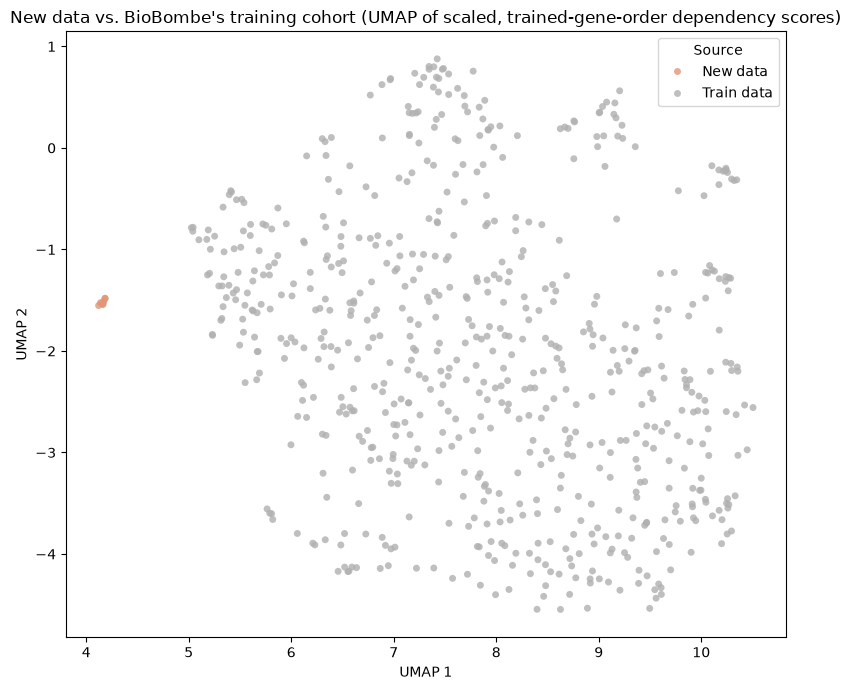

Saved UMAP coordinates (for the later R figure) to data/largaespada/results/NF1_data_umap_coordinates.parquet


In [5]:
# A quick look here, not the final figure — the publication-ready version of
# this plot gets built later in a dedicated R notebook, from the coordinates
# saved below, so this cell only displays inline and saves no image.
plt.figure(figsize=(8, 7))
sns.scatterplot(
    data=combined.sort_values("source"),  # draw training points first so new points sit on top
    x="umap_1", y="umap_2", hue="source",
    palette={"Train data": "#B0B0B0", "New data": "#E29578"},
    s=25, alpha=0.8, edgecolor="none",
)
plt.title("New data vs. BioBombe's training cohort (UMAP of scaled, trained-gene-order dependency scores)")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.legend(title="Source")
plt.tight_layout()
plt.show()

umap_coords_file = data_results_dir / "NF1_data_umap_coordinates.parquet"
combined[["ModelID", "source", "umap_1", "umap_2"]].to_parquet(umap_coords_file, index=False)
print(f"Saved UMAP coordinates (for the later R figure) to {umap_coords_file}")


# ### Per-gene sanity checks on the raw (pre-scaling) values

### Per-gene sanity checks on the raw (pre-scaling) values

In [6]:
# Restricted to the trained genes specifically (scaler_bundle["gene_order"]),
# not DepMap's full ~18,443-gene set: those are the only genes that actually
# reach model inference, and NF1_data_depmap_aligned.parquet's gene-symbol
# harmonization only ever targeted the trained set (see 0.preprocess_raw_data),
# so anything outside it was never checked for a correct alignment in the
# first place and would just be noise here.
new_raw_df = pd.read_parquet(data_results_dir / "NF1_data_depmap_aligned.parquet")
new_raw_values = new_raw_df[gene_order]
train_raw_values = train_raw_df[gene_order]

new_stats = new_raw_values.stack().describe()
train_stats = train_raw_values.stack().describe()

comparison = pd.DataFrame({"new_data": new_stats, "train_data": train_stats})
print("Overall value distribution, new data vs. training data (raw, pre-scaling):")
comparison

Overall value distribution, new data vs. training data (raw, pre-scaling):


,new_data,train_data
count,21648.000000,1.821060e+06
mean,-0.596012,-6.039184e-01
std,0.906160,6.487947e-01
min,-5.365185,-5.465676e+00
25%,-1.112197,-9.547358e-01
50%,-0.364824,-4.063106e-01
75%,0.060266,-1.227767e-01
max,3.986473,2.893550e+00


In [7]:
# Flag genes where the new data's value range looks implausible relative to
# the training data's, e.g. off by an order of magnitude, or a unit mismatch.
train_gene_range = train_raw_values.agg(["min", "max"]).T
new_gene_range = new_raw_values.agg(["min", "max"]).T

range_comparison = train_gene_range.join(new_gene_range, lsuffix="_train", rsuffix="_new", how="inner")
range_comparison["train_span"] = range_comparison["max_train"] - range_comparison["min_train"]
range_comparison["new_span"] = range_comparison["max_new"] - range_comparison["min_new"]
range_comparison["span_ratio"] = range_comparison["new_span"] / range_comparison["train_span"].replace(0, np.nan)

implausible_genes = range_comparison[
    (range_comparison["span_ratio"] > 3) | (range_comparison["span_ratio"] < (1 / 3))
].sort_values("span_ratio", ascending=False)

print(f"{len(implausible_genes)} / {len(range_comparison)} trained genes have a value range "
      "more than 3x wider or narrower than the training data's for that gene.")
implausible_genes.head(20)

393 / 2718 trained genes have a value range more than 3x wider or narrower than the training data's for that gene.


,min_train,max_train,min_new,max_new,train_span,new_span,span_ratio
DARS2 (55157),-1.498719,0.219622,-0.892146,-0.319368,1.718341,0.572779,0.333332
FLOT1 (10211),-1.571863,0.328291,-0.258864,0.374414,1.900154,0.633278,0.333277
RNF8 (9025),-1.896421,0.257692,-1.382917,-0.666679,2.154113,0.716238,0.332498
TDP2 (51567),-1.319818,0.270578,-0.119089,0.409556,1.590396,0.528645,0.332398
ATP6V0A2 (23545),-1.608559,0.122668,-0.042037,0.533267,1.731227,0.575303,0.332310
ESPL1 (9700),-3.347130,-0.561293,-1.067121,-0.141511,2.785837,0.925611,0.332256
DYRK1A (1859),-1.496908,1.264471,-0.778501,0.137889,2.761379,0.916389,0.331859
NDUFB8 (4714),-1.462769,0.179718,-1.132881,-0.588678,1.642487,0.544203,0.331329
SSRP1 (6749),-2.233919,-0.457042,-1.480900,-0.892611,1.776877,0.588289,0.331080
SKIC8 (80349),-2.256536,0.108337,-1.173895,-0.391639,2.364872,0.782256,0.330781


In [8]:
missingness = new_raw_values.isna().mean().sort_values(ascending=False)
print(f"Genes entirely missing from the new data: {(missingness == 1.0).sum()} / {len(missingness)}")
print(f"Genes with any missing values in the new data: {(missingness > 0).sum()} / {len(missingness)}")

sanity_summary = pd.DataFrame({
    "check": [
        "genes_fully_missing", "genes_partially_missing",
        "genes_with_implausible_range", "n_new_samples", "n_trained_genes",
    ],
    "value": [
        int((missingness == 1.0).sum()), int((missingness > 0).sum()),
        len(implausible_genes), new_raw_df.shape[0], range_comparison.shape[0],
    ],
})
sanity_summary.to_parquet(data_results_dir / "distribution_sanity_summary.parquet", index=False)
print(f"\nSaved sanity summary to {data_results_dir / 'distribution_sanity_summary.parquet'}")

Genes entirely missing from the new data: 12 / 2718
Genes with any missing values in the new data: 12 / 2718

Saved sanity summary to data/largaespada/results/distribution_sanity_summary.parquet
